In [1]:
import pandas as pd
import os
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns
import zstandard as zstd
import json
import io
import ast

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
game_names = pd.read_csv('game_names_with_appids_full_year.csv')

In [4]:
folder_reviews = '2025_reviews_combined'
reviews = {}
for file in os.listdir(folder_reviews):
    for game in game_names['appid']:
        if str(game) in file and file.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_reviews, file))
            df['appid'] = game
            reviews[game] = df
            break

In [5]:
len(reviews) 

48

In [28]:
statistics = []
for appid, df in reviews.items():
    game_stats = {
        'appid': appid,
        'num_reviews': len(df),
        'num_upvoted_reviews': df['votes_helpful'].notnull().sum(),
        'num_pos': (df['voted_up'] == 1).sum(),
        'num_neg': (df['voted_up'] == 0).sum(),
    }
    statistics.append(game_stats)

In [29]:
for item in statistics:
    if item['num_reviews'] < 500:
        reviews.pop(item['appid'])
        game_names = game_names[game_names['appid'] != item['appid']]
        statistics.remove(item)

In [8]:
analyser = SentimentIntensityAnalyzer()

def sentiment_analysis(text):
    scores = analyser.polarity_scores(text)
    agg_score = scores['compound']
    return agg_score


In [9]:
all_reviews = pd.concat(reviews.values(), ignore_index=True)
all_reviews.isna().sum()

date              0
voted_up          0
votes_helpful     0
text             88
appid             0
dtype: int64

In [10]:
all_reviews.dropna(subset=['text'], inplace=True)
all_reviews['text'].count()

np.int64(1324051)

In [11]:
#tqdm.pandas(desc="Calculating Sentiment")
#all_reviews['sentiment'] = all_reviews['text'].progress_apply(sentiment_analysis)

In [12]:
#all_reviews.to_csv('all_reviews_with_sentiment.csv', index=False)

In [13]:
all_reviews = pd.read_csv('all_reviews_with_sentiment.csv')

In [14]:
all_reviews['sentiment_binary'] = all_reviews['sentiment'].apply(lambda x: 1 if x >= 0 else 0)

In [15]:
sentiment_scores = all_reviews['sentiment_binary']
sentiment_scores = sentiment_scores.astype(int)
actual_labels = all_reviews['voted_up']
actual_labels = actual_labels.astype(int)
print(classification_report(actual_labels, sentiment_scores))

              precision    recall  f1-score   support

           0       0.49      0.49      0.49    237334
           1       0.89      0.89      0.89   1086717

    accuracy                           0.82   1324051
   macro avg       0.69      0.69      0.69   1324051
weighted avg       0.82      0.82      0.82   1324051



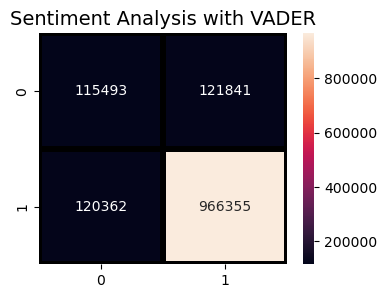

In [16]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(actual_labels, sentiment_scores),
 annot=True,fmt = "d",linecolor="k",linewidths=3)
 
plt.title("Sentiment Analysis with VADER",fontsize=14)
plt.show()

In [17]:
average_sentiment = all_reviews.groupby('appid')['sentiment'].mean().reset_index()
average_sentiment_daily = all_reviews.groupby(['appid', 'date'])['sentiment'].mean().reset_index()
real_sentiment_daily = all_reviews.groupby(['appid', 'date'])['voted_up'].mean().reset_index()

In [18]:
subreddits_all = pd.read_csv('game_subreddits_for_notebook.csv')
subreddits_to_analyse = {}
for game in subreddits_all['appid']:
    if game in game_names['appid'].values:
        subreddits_to_analyse[game] = subreddits_all[subreddits_all['appid'] == game]['subreddits'].values[0]

In [19]:
subreddits_clean = {}
for appid, subreddits_str in subreddits_to_analyse.items():
    actual_subreddit_list = ast.literal_eval(subreddits_str)
    subreddits_clean[appid] = actual_subreddit_list

In [20]:
keywords = {
    730: ["csgo", "cs2", "counter-strike", "counter strike", "global offensive"],
    578080: ["pubg", "playerunknown's battlegrounds", "battlegrounds"],
    570: ["dota 2", "dota", "defense of the ancients"],
    2767030: ["marvel rivals", "rivals"],
    1172470: ["apex legends", "apex"],
    252490: ["rust"],
    2507950: ["delta force", "delta force hawk ops", "dfho"],
    1203220: ["naraka", "naraka bladepoint", "naraka: bladepoint"],
    1623730: ["palworld"],
    238960: ["path of exile", "poe", "poe1", "poe 1"],
    553850: ["helldivers 2", "hd2", "helldivers"],
    230410: ["warframe"],
    1086940: ["baldur's gate 3", "bg3", "baldurs gate 3", "baldur's gate"],
    413150: ["stardew valley", "stardew", "sdv"],
    899770: ["last epoch", "le"],
    431960: ["wallpaper engine"], 
    359550: ["rainbow six siege", "r6", "r6s", "siege", "rainbow 6"],
    552990: ["world of warships", "wows"],
    1973530: ["limbus company", "limbus"],
    381210: ["dead by daylight", "dbd"],
    236390: ["war thunder", "warthunder", "wt"],
    1145350: ["hades 2", "hades ii", "hades2"],
    275850: ["no man's sky", "nms", "no mans sky"],
    2669320: ["ea sports fc 25", "fc25", "fc 25", "fifa 25"],
    1085660: ["destiny 2", "d2"],
    440: ["team fortress 2", "tf2"],
    1174180: ["red dead redemption 2", "rdr2", "red dead 2"],
    294100: ["rimworld"],
    367520: ["hollow knight", "hollowknight"],
    322170: ["geometry dash", "gd"],
    242760: ["the forest"],
    394360: ["hearts of iron iv", "hoi4", "hearts of iron 4", "hearts of iron"],
    1295660: ["civilization vii", "civ 7", "civ7", "civilization 7"],
    1091500: ["cyberpunk 2077", "cp2077", "cyberpunk"],
    1245620: ["elden ring", "eldenring", "er"],
    251570: ["7 days to die", "7dtd"],
    2358720: ["black myth: wukong", "black myth wukong", "bmw", "wukong"],
    289070: ["civilization vi", "civ 6", "civ6", "civilization 6"],
    322330: ["don't starve together", "dont starve together", "dst"],
    1449850: ["yu-gi-oh! master duel", "master duel", "yugioh master duel", "masterduel"],
    261550: ["mount & blade ii", "bannerlord", "mount and blade 2", "mb2"],
    1604030: ["v rising", "vrising"],
    1158310: ["crusader kings iii", "ck3", "crusader kings 3"],
    1366800: ["crosshair x", "crosshairx"], 
    221100: ["dayz"],
    1517290: ["battlefield 2042", "bf2042", "bf 2042"],
    438100: ["vrchat", "vrc"],
    489830: ["skyrim", "the elder scrolls v", "skyrim special edition"]
}

In [21]:
start_2025 = 1735689600
end_2025 = 1767225600

subreddit_dump_folder = "C:/Users/magda/My stuff/Projekty/get data magisterka/reddit_new/reddit/subreddits25"

def extract_subreddit_posts_with_sentiment(subreddit, output_file, keywords):
    relevant_posts = []
    chunk_size = 10000
    if os.path.exists(f'{subreddit_dump_folder}/{subreddit}_submissions.zst'):
        with open(f'{subreddit_dump_folder}/{subreddit}_submissions.zst', 'rb') as f:
            dctx = zstd.ZstdDecompressor()
            stream_reader = dctx.stream_reader(f)
            text_stream = io.TextIOWrapper(stream_reader, encoding='utf-8')
            for line in tqdm(text_stream, desc=f"Scanning {subreddit}", position=1, leave=False):
                try:
                    post = json.loads(line)
                    created_utc = post.get('created_utc')
                    if not created_utc or not (start_2025 <= int(created_utc) < end_2025):
                        continue
                    title = post.get('title', '')
                    body = post.get('selftext', '')
                    full_text = f"{title} {body}"
                    text_lower = full_text.lower()
                    if any(keyword in text_lower for keyword in keywords):
                        sentiment = sentiment_analysis(full_text)
                        relevant_posts.append({
                            'post_id': post.get('id'),
                            'created_utc': created_utc,
                            'subreddit': post.get('subreddit'),
                            'text': full_text,
                            'sentiment': sentiment
                        })
                except json.JSONDecodeError:
                    continue
        if len(relevant_posts) >= chunk_size:
            relevant_df = pd.DataFrame(relevant_posts)
            relevant_df['date'] = pd.to_datetime(relevant_df['created_utc'], unit='s').dt.date
            relevant_df.to_csv(output_file, index=False, mode='a', header=not os.path.exists(output_file))
            relevant_posts.clear()

        if relevant_posts:
            relevant_df = pd.DataFrame(relevant_posts)
            relevant_df['date'] = pd.to_datetime(relevant_df['created_utc'], unit='s').dt.date
            relevant_df.to_csv(output_file, index=False, mode='a', header=not os.path.exists(output_file))


In [22]:
subreddits_clean.items()

dict_items([(730, ['counterstrike2', 'cs2', 'GlobalOffensive', 'counterstrike', 'Csgohacks']), (578080, ['PUBATTLEGROUNDS', 'PUBGConsole', 'PUBG', 'CompetitivePUBG', 'PUBGMobile']), (570, ['DotA2', 'TrueDoTA2', 'Dota2Trade', 'learndota2', 'dotamasterrace']), (2767030, ['marvelrivals', 'MarvelRivalsCirclejer', 'MarvelRivalsLeaks', 'rivals', 'Marvel']), (1172470, ['apexlegends', 'apex_legends', 'ApexLegendsMemes', 'CompetitiveApex', 'ApexOutlands']), (252490, ['rust', 'RustConsole', 'rust_gamedev', 'playrust', 'learnrust']), (2507950, ['deltaforce', 'DeltaForceGlobal', 'DeltaForceMobile', 'SpecOpsArchive', 'MilitaryPorn']), (1203220, ['NarakaBladePoint']), (1623730, ['Palworld', 'PalworldMods', 'PalworldGuide', 'PalMemes', 'TwoBestFriendsPlay']), (238960, ['pathofexile', 'PathOfExileBuilds', 'PathOfExile2']), (553850, ['helldivers2', 'Helldivers', 'HellDiversLeaks', 'LowSodiumHellDivers', 'HelldiversUnfiltered']), (230410, ['Warframe', 'WarframeRunway', 'WarframeRiven', 'memeframe', 'War

In [23]:
#all_tasks = [(appid, sub) for appid, sub_list in subreddits_clean.items() for sub in sub_list]
#for appid, subreddit in tqdm(all_tasks, desc="Overall Progress", position=0, leave=True):
    #extract_subreddit_posts_with_sentiment(subreddit, f'2025_reddit_sentiment/{appid}_{subreddit}_sentiment.csv', keywords[appid])

In [24]:
for appid, subreddit_list in subreddits_clean.items():
    for subreddit in subreddit_list:
        if os.path.exists(f'2025_reddit_sentiment/{appid}_{subreddit}_sentiment.csv'):
            continue
        else:
            print(f"Missing sentiment file for {appid} - {subreddit}")

Missing sentiment file for 1172470 - apex_legends
Missing sentiment file for 1172470 - ApexLegendsMemes
Missing sentiment file for 252490 - rust
Missing sentiment file for 252490 - rust_gamedev
Missing sentiment file for 252490 - learnrust
Missing sentiment file for 2507950 - deltaforce
Missing sentiment file for 2507950 - SpecOpsArchive
Missing sentiment file for 2507950 - MilitaryPorn
Missing sentiment file for 1623730 - PalworldMods
Missing sentiment file for 1623730 - PalworldGuide
Missing sentiment file for 1623730 - PalMemes
Missing sentiment file for 1623730 - TwoBestFriendsPlay
Missing sentiment file for 553850 - HellDiversLeaks
Missing sentiment file for 230410 - WarframeRiven
Missing sentiment file for 413150 - StardewValley
Missing sentiment file for 413150 - FarmsofStardewValley
Missing sentiment file for 413150 - StardewValleyExpanded
Missing sentiment file for 413150 - StardewMemes
Missing sentiment file for 413150 - StardewValleyMods
Missing sentiment file for 431960 - i

In [31]:
subreddit_dfs = {}
for game in game_names['appid']:
    subreddit_dfs[game] = None
    for file in os.listdir('2025_reddit_sentiment'):
        if file.startswith(str(game) + '_'):
            df = pd.read_csv(os.path.join('2025_reddit_sentiment', file))
            df['appid'] = game
            if subreddit_dfs[game] is None:
                subreddit_dfs[game] = df
            else:
                subreddit_dfs[game] = pd.concat([subreddit_dfs[game], df], ignore_index=True)

In [ ]:
single_game_df = subreddit_dfs[730]
print(single_game_df.head())

   post_id   created_utc       subreddit  \
0  1hqsvgn  1.735695e+09  counterstrike2   
1  1hqul44  1.735702e+09  counterstrike2   
2  1hr9nu1  1.735758e+09  counterstrike2   
3  1hrbfsn  1.735763e+09  counterstrike2   
4  1hri6ur  1.735781e+09  counterstrike2   

                                                text  sentiment        date  \
0  Cs2 Bug screen (help me) Ive got this weird bu...     0.8407  2025-01-01   
1  Audio Device Not Working https://preview.redd....    -0.6665  2025-01-01   
2                                 cs2 girl brainrot      0.0000  2025-01-01   
3               40 CS2 Tips You Can Steal From Pros     -0.4939  2025-01-01   
4  CS2 Serrver Blocking? Any Chance to skip or bl...    -0.7059  2025-01-02   

   appid  
0    730  
1    730  
2    730  
3    730  
4    730  
91778


In [36]:
print(len(single_game_df))

91778


In [34]:
statistics_reddit = []
for appid, df in subreddit_dfs.items():
    game_stats = {
        'appid': appid,
        'num_posts': len(df) if df is not None else 0,
        'start_date': pd.to_datetime(df['created_utc'], unit='s').min() if df is not None else None,
        'end_date': pd.to_datetime(df['created_utc'], unit='s').max() if df is not None else None
    }
    statistics_reddit.append(game_stats)

In [38]:
for item in statistics_reddit:
    if item['num_posts'] < 500:
        subreddit_dfs.pop(item['appid'])
        game_names = game_names[game_names['appid'] != item['appid']]
        statistics_reddit.remove(item)

In [39]:
all_posts = pd.concat(subreddit_dfs.values(), ignore_index=True)
average_sentiment_reddit = all_posts.groupby('appid')['sentiment'].mean().reset_index()
average_sentiment_reddit_daily = all_posts.groupby(['appid', 'date'])['sentiment'].mean().reset_index()

In [45]:
average_daily_reviews_pivot = average_sentiment_daily.pivot(index='date', columns='appid', values='sentiment')
average_daily_reddit_pivot = average_sentiment_reddit_daily.pivot(index='date', columns='appid', values='sentiment')

In [48]:
average_daily_reddit_pivot.to_csv('average_sentiment_reddit_daily.csv', index=True)
average_daily_reviews_pivot.to_csv('average_sentiment_reviews_daily.csv', index=True)
game_names.to_csv('game_names_after_sentiment_analysis.csv', index=False)